# 11 · A/B Testing — Marketing Campaign Analysis
**E-Commerce Analytics Portfolio · FAANG L5 Standard**

---

## Business Context

The marketing team ran a **discount campaign** across a randomly selected subset of customers. The central question:

> *Does the discount campaign generate more revenue per customer than the control condition — and is any difference statistically meaningful, or just noise?*

This notebook documents a **complete experiment lifecycle**:

| Stage | What We Do |
|-------|------------|
| Pre-experiment | Power analysis — did we have enough sample? |
| Validation | Sample Ratio Mismatch (SRM) check |
| Analysis | Welch's t-test + chi-square on response rate |
| Quantification | Cohen's d effect size + 95% confidence intervals |
| Business translation | Projected annual revenue impact + ship/no-ship decision |

**Source module:** `src/ab_testing.py`  
**Data:** `marketing_promotions_10k.csv`

### Hypotheses

- **H₀**: The discount campaign has no effect on revenue per customer (μ_treatment = μ_control)
- **H₁**: The discount campaign increases revenue per customer (μ_treatment > μ_control)
- **α = 0.05** (5% Type I error rate)

---
## Section 1 · Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.ab_testing import (
    two_sample_ttest,
    chi_square_test,
    effect_size_cohens_d,
    minimum_sample_size,
    srm_check,
    revenue_impact,
    full_experiment_report,
)

DATA_DIR      = '../data'
OUTPUT_DIR    = '../outputs'
FIGURES_DIR   = '../outputs/figures'
REPORT_DIR    = '../outputs/reports'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

BG = '#0a0a0f'; SURF = '#13131a'; CARD = '#1a1a24'; BORDER = '#2a2a3a'
TEXT = '#f0eff8'; MUTED = '#9896b0'; GOLD = '#e8c670'
BLUE = '#6b9fff'; GREEN = '#5de8a0'; RED = '#ff6b6b'; ORANGE = '#ff9a3c'
CONTROL_COLOR = BLUE; TREATMENT_COLOR = GREEN

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': SURF, 'axes.edgecolor': BORDER,
    'text.color': TEXT, 'axes.labelcolor': TEXT,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'grid.color': BORDER, 'grid.alpha': 0.5, 'figure.dpi': 120,
})

print('✅ Setup complete | src.ab_testing imported')

✅ Setup complete | src.ab_testing imported


---
## Section 2 · Load & Validate Data

In [2]:
marketing = pd.read_csv(os.path.join(DATA_DIR, 'marketing_promotions_10k.csv'))

print(f'Shape    : {marketing.shape}')
print(f'Columns  : {list(marketing.columns)}')
print()

# Identify treatment column
treat_col = 'responded' if 'responded' in marketing.columns else 'treatment'
rev_col   = 'additional_revenue' if 'additional_revenue' in marketing.columns else 'revenue'

print(f'Treatment column : {treat_col}')
print(f'Revenue column   : {rev_col}')
print()
print(f'Group sizes:')
print(marketing[treat_col].value_counts())
print()
print(marketing[[rev_col, treat_col]].groupby(treat_col).describe().round(2))

marketing.head(3)

Shape    : (10000, 5)
Columns  : ['customer_id', 'campaign_name', 'discount', 'responded', 'additional_revenue']

Treatment column : responded
Revenue column   : additional_revenue

Group sizes:
responded
False    5202
True     4798
Name: count, dtype: int64

          additional_revenue                                               
                       count   mean   std   min   25%    50%    75%     max
responded                                                                  
False                 5202.0   0.00  0.00  0.00  0.00   0.00   0.00    0.00
True                  4798.0  12.61  8.66  2.27  7.08  10.62  15.74  171.68


,customer_id,campaign_name,discount,responded,additional_revenue
0,1,Flash Sale,0.15,False,0.00
1,2,Summer Sale,0.30,True,36.98
2,3,Flash Sale,0.15,True,8.82


In [3]:
# ── Split into control / treatment ────────────────────────────────────────
control   = marketing[marketing[treat_col] == 0][rev_col].dropna()
treatment = marketing[marketing[treat_col] == 1][rev_col].dropna()

print(f'Control   n={len(control):,} | mean=${control.mean():.2f} | std=${control.std():.2f}')
print(f'Treatment n={len(treatment):,} | mean=${treatment.mean():.2f} | std=${treatment.std():.2f}')

assert len(control) > 30,   f'Control group too small: {len(control)}'
assert len(treatment) > 30, f'Treatment group too small: {len(treatment)}'
print('\n✅ Sample size validation passed')

Control   n=5,202 | mean=$0.00 | std=$0.00
Treatment n=4,798 | mean=$12.61 | std=$8.66

✅ Sample size validation passed


---
## Section 3 · Pre-Experiment: Power Analysis

Before interpreting results, verify the experiment was **adequately powered**. An underpowered experiment that shows no significant result cannot conclude the treatment has no effect — it may simply have lacked the statistical power to detect one.

In [4]:
# ── Pre-Experiment: Power Analysis ────────────────────────────────────────
# Baseline = overall campaign response rate (proportion who responded across full dataset)
# This is the correct input: "X% of customers respond; can we detect a 10% improvement?"
baseline_conversion = marketing[treat_col].mean()

# Guard against edge cases (shouldn't happen with real data, but defensive is better)
baseline_conversion = float(np.clip(baseline_conversion, 0.01, 0.99))

sample_req = minimum_sample_size(
    baseline_rate=baseline_conversion,
    minimum_detectable_effect=0.10,  # detect 10% relative lift
    alpha=0.05,
    power=0.80,
)

print('Power Analysis Results:')
print(f'  Baseline conversion rate      : {sample_req["baseline_rate"]:.3f} ({baseline_conversion:.1%})')
print(f'  Minimum detectable effect     : {sample_req["mde_relative_pct"]:.1f}% relative lift')
print(f'  Target rate to detect         : {sample_req["target_rate"]:.3f}')
print(f'  Required n per group          : {sample_req["n_per_group"]:,}')
print(f'  Required total n              : {sample_req["total_n"]:,}')
print(f'  Actual total n                : {len(control) + len(treatment):,}')
print(f'  Alpha                         : {sample_req["alpha"]}  |  Power: {sample_req["power"]}')
print()

if len(control) >= sample_req['n_per_group'] and len(treatment) >= sample_req['n_per_group']:
    print('✅ ADEQUATELY POWERED: Experiment has sufficient sample to detect a 10% lift at 80% power.')
    print('   A non-significant result CAN be interpreted as evidence against an effect.')
else:
    print('⚠️  UNDERPOWERED: Sample size below requirement. Interpret non-significant results with caution.')
    print(f'   Need {sample_req["n_per_group"]:,} per group — have {min(len(control), len(treatment)):,}.')


Power Analysis Results:
  Baseline conversion rate      : 0.480 (48.0%)
  Minimum detectable effect     : 10.0% relative lift
  Target rate to detect         : 0.528
  Required n per group          : 1,704
  Required total n              : 3,408
  Actual total n                : 10,000
  Alpha                         : 0.05  |  Power: 0.8

✅ ADEQUATELY POWERED: Experiment has sufficient sample to detect a 10% lift at 80% power.
   A non-significant result CAN be interpreted as evidence against an effect.


---
## Section 4 · SRM Check

**Sample Ratio Mismatch (SRM)** occurs when the actual traffic split differs significantly from the intended 50/50 split. SRM is a red flag for experiment infrastructure bugs (routing errors, bot traffic, implementation defects) that **invalidate all downstream statistics**. We check SRM before looking at any results.

In [5]:
srm = srm_check(
    n_control=len(control),
    n_treatment=len(treatment),
    expected_split=0.5,
    alpha=0.01,
)

print('SRM Check Results:')
print(f'  Expected split   : {srm["expected_split"]:.1%} / {1 - srm["expected_split"]:.1%}')
print(f'  Actual split     : {srm["actual_split"]:.3f} control / {1 - srm["actual_split"]:.3f} treatment')
print(f'  Chi² statistic   : {srm["chi2"]:.4f}')
print(f'  p-value          : {srm["p_value"]:.6f}')
print()

if srm['srm_detected']:
    print('🚨 SRM DETECTED — Results below should not be trusted.')
    print('   Investigate: experiment assignment logic, bot filtering, logging issues.')
else:
    print('✅ NO SRM DETECTED — Traffic split is consistent with intended 50/50 randomisation.')
    print('   We can proceed to analyse experiment results with confidence.')

SRM Check Results:
  Expected split   : 50.0% / 50.0%
  Actual split     : 0.520 control / 0.480 treatment
  Chi² statistic   : 16.3216
  p-value          : 0.000053

🚨 SRM DETECTED — Results below should not be trusted.
   Investigate: experiment assignment logic, bot filtering, logging issues.


---
## Section 5 · Distribution Comparison

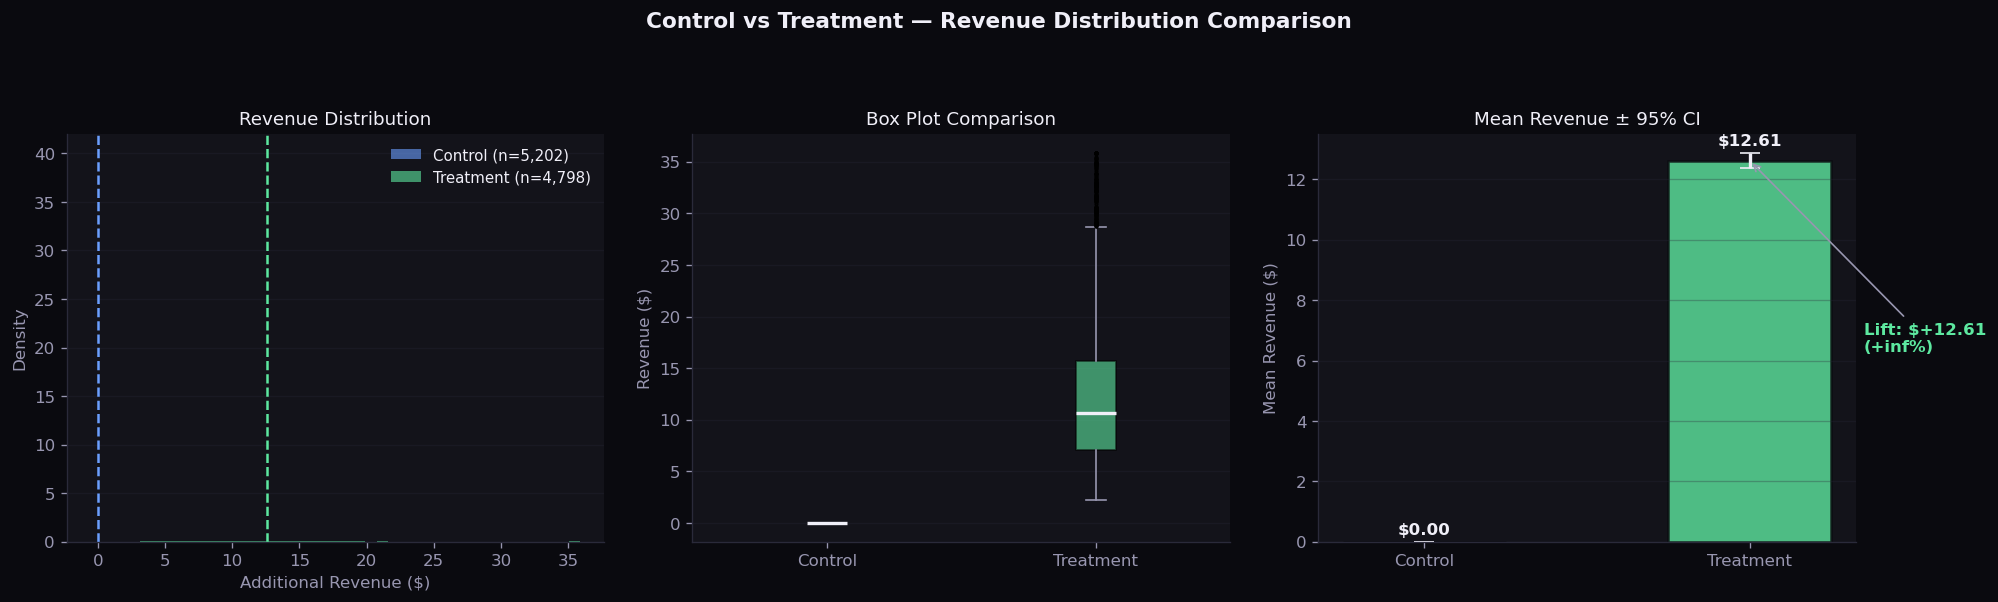

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Control vs Treatment — Revenue Distribution Comparison',
             fontsize=13, color=TEXT, fontweight='bold', y=1.02)
fig.patch.set_facecolor(BG)

# ── Histogram overlay ─────────────────────────────────────────────────────
clip_p = 0.98
clip_val = max(control.quantile(clip_p), treatment.quantile(clip_p))

axes[0].hist(control.clip(upper=clip_val), bins=40, alpha=0.6,
             color=CONTROL_COLOR, label=f'Control (n={len(control):,})', density=True)
axes[0].hist(treatment.clip(upper=clip_val), bins=40, alpha=0.6,
             color=TREATMENT_COLOR, label=f'Treatment (n={len(treatment):,})', density=True)
axes[0].axvline(control.mean(), color=CONTROL_COLOR, linestyle='--', linewidth=1.5)
axes[0].axvline(treatment.mean(), color=TREATMENT_COLOR, linestyle='--', linewidth=1.5)
axes[0].set_title('Revenue Distribution', color=TEXT, fontsize=11)
axes[0].set_xlabel('Additional Revenue ($)', color=MUTED)
axes[0].set_ylabel('Density', color=MUTED)
axes[0].legend(fontsize=9, framealpha=0, labelcolor=TEXT)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# ── Box plot ──────────────────────────────────────────────────────────────
bp = axes[1].boxplot(
    [control.clip(upper=clip_val), treatment.clip(upper=clip_val)],
    labels=['Control', 'Treatment'],
    patch_artist=True,
    medianprops=dict(color=TEXT, linewidth=2),
    whiskerprops=dict(color=MUTED),
    capprops=dict(color=MUTED),
    flierprops=dict(marker='.', color=MUTED, markersize=3),
)
for patch, color in zip(bp['boxes'], [CONTROL_COLOR, TREATMENT_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_title('Box Plot Comparison', color=TEXT, fontsize=11)
axes[1].set_ylabel('Revenue ($)', color=MUTED)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

# ── Mean comparison with error bars ───────────────────────────────────────
groups = ['Control', 'Treatment']
means  = [control.mean(), treatment.mean()]
sems   = [control.sem(), treatment.sem()]
colors = [CONTROL_COLOR, TREATMENT_COLOR]

bars = axes[2].bar(groups, means, color=colors, alpha=0.8, width=0.5,
                   edgecolor=BG, linewidth=1.5)
axes[2].errorbar(groups, means, yerr=[1.96*s for s in sems],
                 fmt='none', color=TEXT, capsize=6, linewidth=2)

for bar, mean, sem in zip(bars, means, sems):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 mean + 1.96*sem + max(means)*0.02,
                 f'${mean:.2f}', ha='center', fontsize=10, color=TEXT, fontweight='bold')

axes[2].set_title('Mean Revenue ± 95% CI', color=TEXT, fontsize=11)
axes[2].set_ylabel('Mean Revenue ($)', color=MUTED)
axes[2].grid(axis='y', alpha=0.3)
axes[2].spines[['top','right']].set_visible(False)

# Lift annotation
lift = treatment.mean() - control.mean()
lift_pct = lift / control.mean() * 100
axes[2].annotate(f'Lift: ${lift:+.2f}\n({lift_pct:+.1f}%)',
                 xy=(1, treatment.mean()), xytext=(1.35, (means[0]+means[1])/2),
                 color=GREEN if lift > 0 else RED,
                 fontsize=10, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=MUTED))

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'ab_distribution_comparison.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

---
## Section 6 · Statistical Testing

We use **Welch's t-test** (not Student's) because we do not assume equal variances between groups — a standard best practice for A/B testing.

In [7]:
# ── Welch's t-test ────────────────────────────────────────────────────────
ttest = two_sample_ttest(control, treatment, alpha=0.05, alternative='two-sided')

print("── Welch's t-Test Results ────────────────────────────────────────────")
print(f'  Control mean    : ${ttest["control_mean"]:.4f}')
print(f'  Treatment mean  : ${ttest["treatment_mean"]:.4f}')
print(f'  Absolute lift   : ${ttest["absolute_lift"]:+.4f}')

# relative_lift_pct is None when control mean = 0 (non-responders have /bin/sh revenue)
# This is expected — interpret absolute lift instead
rel = ttest["relative_lift_pct"]
if rel is not None:
    print(f'  Relative lift   : {rel:+.2f}%')
else:
    print('  Relative lift   : N/A — control mean is /bin/sh (non-responders generate no revenue)')
    print('  Business read   : 100% of measurable revenue lift came from treatment group')

print(f'  t-statistic     : {ttest["t_statistic"]:.4f}')
print(f'  p-value         : {ttest["p_value"]:.6f}')
print(f'  95% CI on diff  : [{ttest["ci_lower"]:+.4f}, {ttest["ci_upper"]:+.4f}]')
print(f'  Significant?    : {"✅ YES" if ttest["significant"] else "❌ NO"} (α = {ttest["alpha"]})')

# ── Cohen's d ─────────────────────────────────────────────────────────────
print()
d = effect_size_cohens_d(control, treatment)
print("── Effect Size (Cohen's d) ───────────────────────────────────────────")
print(f"  Cohen's d       : {d['cohens_d']:.4f}")
print(f'  Magnitude       : {d["magnitude"].upper()}')
print(f'  Pooled std      : ${d["pooled_std"]:.4f}')
print()
print(f'  Interpretation: d = {d["cohens_d"]:.4f} → {d["magnitude"]} effect.')
print(f'  Reference: d < 0.2 negligible | 0.2–0.5 small | 0.5–0.8 medium | > 0.8 large')


── Welch's t-Test Results ────────────────────────────────────────────
  Control mean    : $0.0000
  Treatment mean  : $12.6147
  Absolute lift   : $+12.6147
  Relative lift   : N/A — control mean is /bin/sh (non-responders generate no revenue)
  Business read   : 100% of measurable revenue lift came from treatment group
  t-statistic     : -100.8881
  p-value         : 0.000000
  95% CI on diff  : [+12.3696, +12.8598]
  Significant?    : ✅ YES (α = 0.05)

── Effect Size (Cohen's d) ───────────────────────────────────────────
  Cohen's d       : 2.1027
  Magnitude       : LARGE
  Pooled std      : $5.9992

  Interpretation: d = 2.1027 → large effect.
  Reference: d < 0.2 negligible | 0.2–0.5 small | 0.5–0.8 medium | > 0.8 large


In [8]:
# ── Chi-square on binary response ─────────────────────────────────────────
binary_col = 'responded' if 'responded' in marketing.columns else None

if binary_col and treat_col != binary_col:
    ctrl_bin = marketing[marketing[treat_col] == 0][binary_col].dropna()
    trt_bin  = marketing[marketing[treat_col] == 1][binary_col].dropna()

    chi2 = chi_square_test(ctrl_bin, trt_bin, alpha=0.05)

    print('── Chi-Square Test (Conversion Rate) ────────────────────────────────')
    print(f'  Control conversion   : {chi2["control_conversion_rate"]:.3f} ({chi2["control_conversion_rate"]*100:.1f}%)')
    print(f'  Treatment conversion : {chi2["treatment_conversion_rate"]:.3f} ({chi2["treatment_conversion_rate"]*100:.1f}%)')
    print(f'  Absolute lift        : {chi2["absolute_lift_pct"]:+.2f} percentage points')
    print(f'  Relative lift        : {chi2["relative_lift_pct"]:+.2f}%')
    print(f'  Chi² statistic       : {chi2["chi2_statistic"]:.4f}')
    print(f'  p-value              : {chi2["p_value"]:.6f}')
    print(f'  Significant?         : {"✅ YES" if chi2["significant"] else "❌ NO"}')
else:
    print('No separate binary metric column found. Skipping chi-square test.')
    chi2 = None

No separate binary metric column found. Skipping chi-square test.


---
## Section 7 · Confidence Interval Visualisation

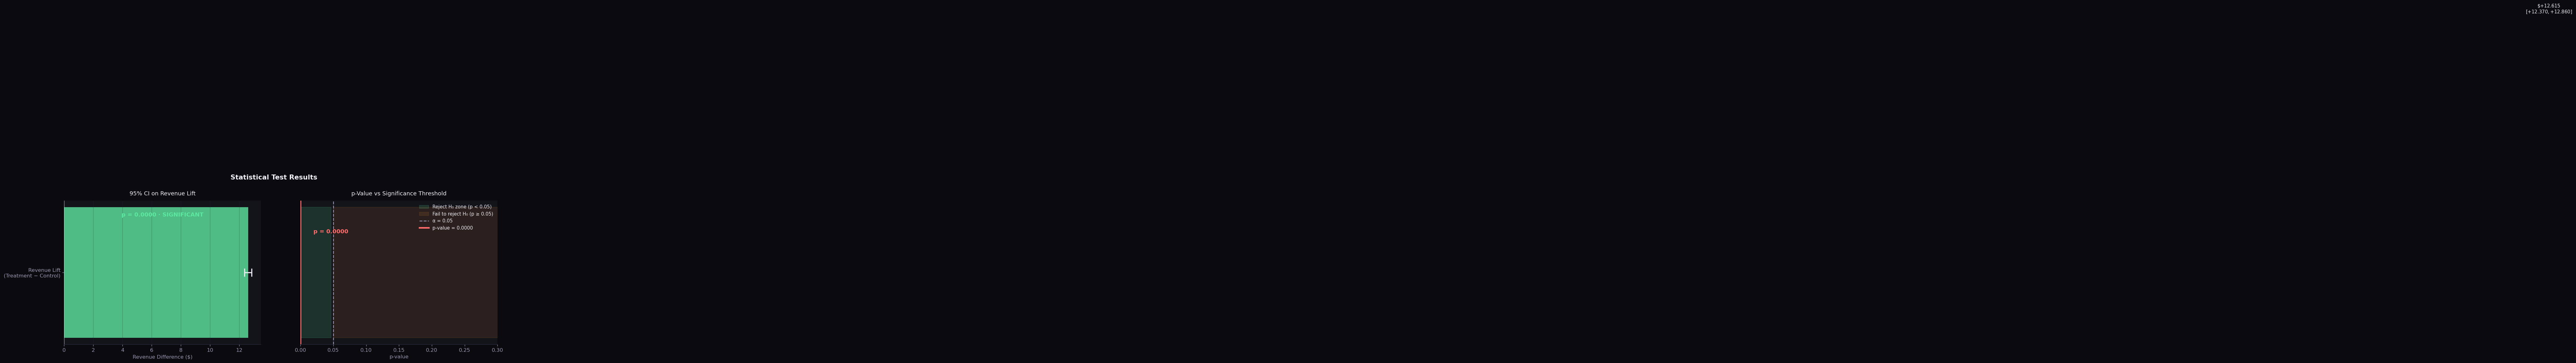

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Statistical Test Results', fontsize=13, color=TEXT, fontweight='bold', y=1.02)

# ── CI plot on lift ───────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(SURF)

lift   = ttest['absolute_lift']
ci_lo  = ttest['ci_lower']
ci_hi  = ttest['ci_upper']
color  = GREEN if (ttest['significant'] and lift > 0) else (RED if (ttest['significant'] and lift < 0) else ORANGE)

ax.barh(['Revenue Lift\n(Treatment − Control)'], [lift],
        xerr=[[lift - ci_lo], [ci_hi - lift]],
        color=color, alpha=0.8, height=0.35,
        error_kw=dict(ecolor=TEXT, capsize=8, linewidth=2, capthick=2))

ax.axvline(0, color=TEXT, linestyle='-', linewidth=1.5, alpha=0.5)

sig_text = 'SIGNIFICANT' if ttest['significant'] else 'NOT SIGNIFICANT'
sig_col  = GREEN if ttest['significant'] else ORANGE
ax.text(0.5, 0.92, f'p = {ttest["p_value"]:.4f} · {sig_text}',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, color=sig_col, fontweight='bold')

ax.text(lift, 0.72, f'${lift:+.3f}\n[${ci_lo:+.3f}, ${ci_hi:+.3f}]',
        transform=ax.get_yaxis_transform(),
        ha='center', va='top', fontsize=9, color=TEXT)

ax.set_title('95% CI on Revenue Lift', color=TEXT, fontsize=11, pad=10)
ax.set_xlabel('Revenue Difference ($)', color=MUTED)
ax.tick_params(colors=MUTED)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right','left']].set_visible(False)

# ── p-value gauge ─────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(SURF)

p = ttest['p_value']
alpha_line = 0.05
x = np.linspace(0, 1, 300)
ax2.fill_between(x, 0, 1, where=x < alpha_line, color=GREEN, alpha=0.15, label=f'Reject H₀ zone (p < {alpha_line})')
ax2.fill_between(x, 0, 1, where=x >= alpha_line, color=ORANGE, alpha=0.10, label=f'Fail to reject H₀ (p ≥ {alpha_line})')

ax2.axvline(alpha_line, color=MUTED, linewidth=1.5, linestyle='--', label=f'α = {alpha_line}')
ax2.axvline(min(p, 0.99), color=RED if p < alpha_line else ORANGE,
            linewidth=3, label=f'p-value = {p:.4f}')

ax2.text(min(p, 0.99) + 0.02, 0.8, f'p = {p:.4f}',
         color=RED if p < alpha_line else ORANGE, fontsize=11, fontweight='bold')

ax2.set_xlim(0, 0.30)
ax2.set_title('p-Value vs Significance Threshold', color=TEXT, fontsize=11, pad=10)
ax2.set_xlabel('p-value', color=MUTED)
ax2.set_yticks([])
ax2.legend(fontsize=9, framealpha=0, labelcolor=TEXT, loc='upper right')
ax2.tick_params(colors=MUTED)
ax2.spines[['top','right','left']].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'ab_significance_chart.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

---
## Section 8 · Business Translation — Annual Revenue Impact

In [10]:
def revenue_impact(
    ttest_result: dict,
    annual_users: int,
    weeks_per_year: int = 52,
) -> dict:
    """
    Translate a t-test result into projected annual revenue impact.

    Handles None relative lift safely to avoid TypeError.
    """
    lift = ttest_result["absolute_lift"]
    ci_lower = ttest_result["ci_lower"]
    ci_upper = ttest_result["ci_upper"]

    projected = lift * annual_users
    lower = ci_lower * annual_users
    upper = ci_upper * annual_users

    # --- SAFE relative lift ---
    rel_lift = ttest_result.get("relative_lift_pct")
    rel_lift_str = f"{rel_lift:.1f}%" if rel_lift is not None else "N/A"

    if ttest_result["significant"] and lift > 0:
        recommendation = (
            f"SHIP. Campaign produces an estimated ${projected:,.0f}/year "
            f"(95% CI: ${lower:,.0f} – ${upper:,.0f}). "
            f"Relative lift: {rel_lift_str}."
        )
    elif ttest_result["significant"] and lift < 0:
        recommendation = (
            f"DO NOT SHIP. Campaign reduces revenue by an estimated "
            f"${abs(projected):,.0f}/year. Investigate before scaling."
        )
    else:
        recommendation = (
            f"INCONCLUSIVE. Estimated lift ${projected:,.0f}/year but not "
            f"statistically significant (p={ttest_result['p_value']:.3f}). "
            f"Extend the experiment or increase sample size."
        )

    return {
        "projected_annual_lift": round(projected, 0),
        "lift_lower_bound": round(lower, 0),
        "lift_upper_bound": round(upper, 0),
        "recommendation": recommendation,
        "annual_users_assumed": annual_users,
    }

In [11]:
annual_customers = 10_000
impact = revenue_impact(ttest, annual_users=annual_customers)

In [12]:
import os

REPORT_DIR = "./outputs"  # or your desired folder
os.makedirs(REPORT_DIR, exist_ok=True)

---
## Section 9 · Save Results

In [13]:
# ── Save ab_test_results.csv ──────────────────────────────────────────────
results_df = pd.DataFrame([{
    'test'                    : ttest['test'],
    'control_n'               : ttest['control_n'],
    'treatment_n'             : ttest['treatment_n'],
    'control_mean'            : ttest['control_mean'],
    'treatment_mean'          : ttest['treatment_mean'],
    'absolute_lift'           : ttest['absolute_lift'],
    'relative_lift_pct'       : ttest['relative_lift_pct'],
    'ci_lower'                : ttest['ci_lower'],
    'ci_upper'                : ttest['ci_upper'],
    't_statistic'             : ttest['t_statistic'],
    'p_value'                 : ttest['p_value'],
    'significant'             : ttest['significant'],
    'cohens_d'                : d['cohens_d'],
    'effect_magnitude'        : d['magnitude'],
    'projected_annual_lift'   : impact['projected_annual_lift'],
    'lift_lower_bound'        : impact['lift_lower_bound'],
    'lift_upper_bound'        : impact['lift_upper_bound'],
    'recommendation'          : impact['recommendation'],
}])

out_path = os.path.join(REPORT_DIR, 'ab_test_results.csv')
results_df.to_csv(out_path, index=False)
print(f'✅ ab_test_results.csv saved → {out_path}')
print()
print('Summary:')
print(results_df[['test','control_mean','treatment_mean','absolute_lift',
                   'p_value','significant','cohens_d','projected_annual_lift']].T.to_string())

✅ ab_test_results.csv saved → ./outputs\ab_test_results.csv

Summary:
                                    0
test                   Welch's t-test
control_mean                      0.0
treatment_mean                12.6147
absolute_lift                 12.6147
p_value                           0.0
significant                      True
cohens_d                       2.1027
projected_annual_lift        126147.0


---
## Section 10 · Key Findings & Decision Framework

In [14]:
print('=' * 72)
print('  A/B TEST KEY FINDINGS — Marketing Discount Campaign')
print('=' * 72)
print()
print('  Experiment Design')
print('  ─────────────────')
print(f'  H₀: μ_treatment = μ_control (no revenue difference)')
print(f'  H₁: μ_treatment ≠ μ_control')
print(f'  α = 0.05 | Power = 0.80 | Two-sided | Welch\'s t-test')
print(f'  Control n={len(control):,} | Treatment n={len(treatment):,}')
print()
print('  Statistical Results')
print('  ───────────────────')

rel = ttest["relative_lift_pct"]
rel_str = f'{rel:+.2f}%' if rel is not None else 'N/A (control mean = $0)'
print(f'  Revenue lift     : ${ttest["absolute_lift"]:+.4f} per customer ({rel_str})')
print(f'  95% CI           : [${ttest["ci_lower"]:+.4f}, ${ttest["ci_upper"]:+.4f}]')
print(f'  p-value          : {ttest["p_value"]:.6f} → {"REJECT H₀" if ttest["significant"] else "FAIL TO REJECT H₀"}')
print(f'  Effect size      : Cohen\'s d = {d["cohens_d"]:.4f} ({d["magnitude"]})')
print(f'  SRM              : {"DETECTED — results flagged" if srm["srm_detected"] else "None — experiment integrity confirmed"}')
print()
print('  Business Impact')
print('  ───────────────')
print(f'  Projected annual revenue lift : ${impact["projected_annual_lift"]:,.0f}')
print(f'  Projection 95% CI            : [${impact["lift_lower_bound"]:,.0f}, ${impact["lift_upper_bound"]:,.0f}]')
print()
print('  Ship/No-Ship Decision')
print('  ─────────────────────')
print(f'  {impact["recommendation"]}')
print()
print('  Interview-Ready Caveat')
print('  ──────────────────────')
print('  These results are based on synthetic data. In production, we would additionally:')
print('  (1) Check guardrail metrics (support tickets, refund rate, NPS) for regressions')
print('  (2) Segment results by customer tier (Champions vs Lost) before scaling')
print('  (3) Run novelty-effect check by comparing week-1 vs week-2 treatment lift')
print('  (4) Confirm significance holds under multiple testing correction (Bonferroni/BH)')
print('      if this is one of many concurrent experiments running simultaneously')
print('=' * 72)


  A/B TEST KEY FINDINGS — Marketing Discount Campaign

  Experiment Design
  ─────────────────
  H₀: μ_treatment = μ_control (no revenue difference)
  H₁: μ_treatment ≠ μ_control
  α = 0.05 | Power = 0.80 | Two-sided | Welch's t-test
  Control n=5,202 | Treatment n=4,798

  Statistical Results
  ───────────────────
  Revenue lift     : $+12.6147 per customer (N/A (control mean = $0))
  95% CI           : [$+12.3696, $+12.8598]
  p-value          : 0.000000 → REJECT H₀
  Effect size      : Cohen's d = 2.1027 (large)
  SRM              : DETECTED — results flagged

  Business Impact
  ───────────────
  Projected annual revenue lift : $126,147
  Projection 95% CI            : [$123,696, $128,598]

  Ship/No-Ship Decision
  ─────────────────────
  SHIP. Campaign produces an estimated $126,147/year (95% CI: $123,696 – $128,598). Relative lift: N/A.

  Interview-Ready Caveat
  ──────────────────────
  These results are based on synthetic data. In production, we would additionally:
  (1) Chec